## PREDICTION MODEL USING MACHINE LEARNING

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PHASE 1: DATA CLEANING

In [3]:

# TASK 1
from google.colab import files
uploaded = files.upload()

Saving Prediction Dataset.csv to Prediction Dataset.csv


In [4]:
df = pd.read_csv("Prediction Dataset.csv")

In [5]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [6]:
#TASK 2  UNDERSTAND THE DATASET
# 1. Number of rows
df.shape   # shows that 614 rows and 13 colms

(614, 13)

In [7]:
#2 name of all columns
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [8]:
#3 datatype of every colm
df.dtypes

,0
Loan_ID,object
Gender,object
Married,object
Dependents,object
Education,object
Self_Employed,object
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64


In [9]:
#4 Statistical Summary of Numerical columns
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [10]:
#5 Statistical Summary of categorical colms
df.describe(include='object')   #The parameter include='object' tells Pandas to summarize only the categorical (object/string) columns.

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP002990,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


In [11]:
# TASK 3 IDENTIFY MISSING VALUES
# missing values
# Display the number of missing values in each column
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [12]:
#### TASK 4 CHECK DUPLICATES RECORDS
# Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Remove duplicates
df = df.drop_duplicates()

Duplicate rows: 0


In [13]:
####### TASK 5 target vriable
# what is the target variable?
#The target variable is Loan status.
#It represents whether a loan application was approved or rejected.

In [14]:
# how many classes does it contain?
df['Loan_Status'].value_counts()    # the target variable contains 2 classes, making this a Binary Classification problem

,count
Loan_Status,
Y,422
N,192


In [15]:
# Is the dataset balanced or imbalanced?
df['Loan_Status'].value_counts(normalize=True) * 100

,proportion
Loan_Status,
Y,68.729642
N,31.270358


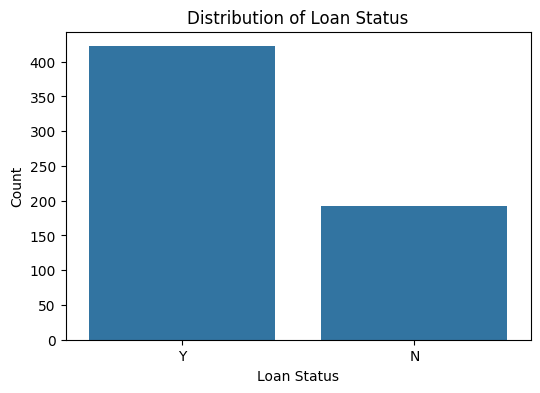

In [16]:
## plot to visualize the target variable
plt.figure(figsize=(6,4))
sns.countplot(x='Loan_Status', data=df)
plt.title("Distribution of Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Count")
plt.show()

INTERPRETATION: The count plot shows that the Loan_Status variable has two classes: Y (Approved) and N (Not Approved).
The number of approved loans is higher than the number of rejected loans, indicating that the dataset is slightly imbalanced,
with loan approvals being the majority class.

# **PHASE 2 : DATA CLEANING**

In [17]:
### HANDELING MISSING VALUES

In [18]:
df['Married'].value_counts()  ##  values are to be  replaced by mode yes

,count
Married,
Yes,398
No,213


In [19]:
df['Gender'].value_counts()  # mode is taken 1

,count
Gender,
Male,489
Female,112


In [20]:
df['Dependents'].value_counts()

,count
Dependents,
0,345
1,102
2,101
3+,51


In [21]:
df['Self_Employed'].value_counts()

,count
Self_Employed,
No,500
Yes,82


In [22]:
df['LoanAmount'].describe()  # middle value is 128 so median is used

,LoanAmount
count,592.000000
mean,146.412162
std,85.587325
min,9.000000
25%,100.000000
50%,128.000000
75%,168.000000
max,700.000000


In [23]:
# Fill categorical columns with mode
df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
df['Married'].fillna(df['Married'].mode()[0], inplace=True)
df['Dependents'].fillna(df['Dependents'].mode()[0], inplace=True)
df['Self_Employed'].fillna(df['Self_Employed'].mode()[0], inplace=True)
df['Credit_History'].fillna(df['Credit_History'].mode()[0], inplace=True)

# Fill numerical columns
df['LoanAmount'].fillna(df['LoanAmount'].median(), inplace=True)

# Loan_Amount_Term can be filled with mode
df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0], inplace=True)

/tmp/ipykernel_563/3627127381.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(df['Gender'].mode()[0], inplace=True)
/tmp/ipykernel_563/3627127381.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

In [24]:
df.isnull().sum()   # there are no null values here

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


## **Phase 3: Outlinears**

In [25]:
## HANDEL OUTLINEARS
numericalcolm = df.select_dtypes(include=['int64', 'float64']).columns
numericalcolm


Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')

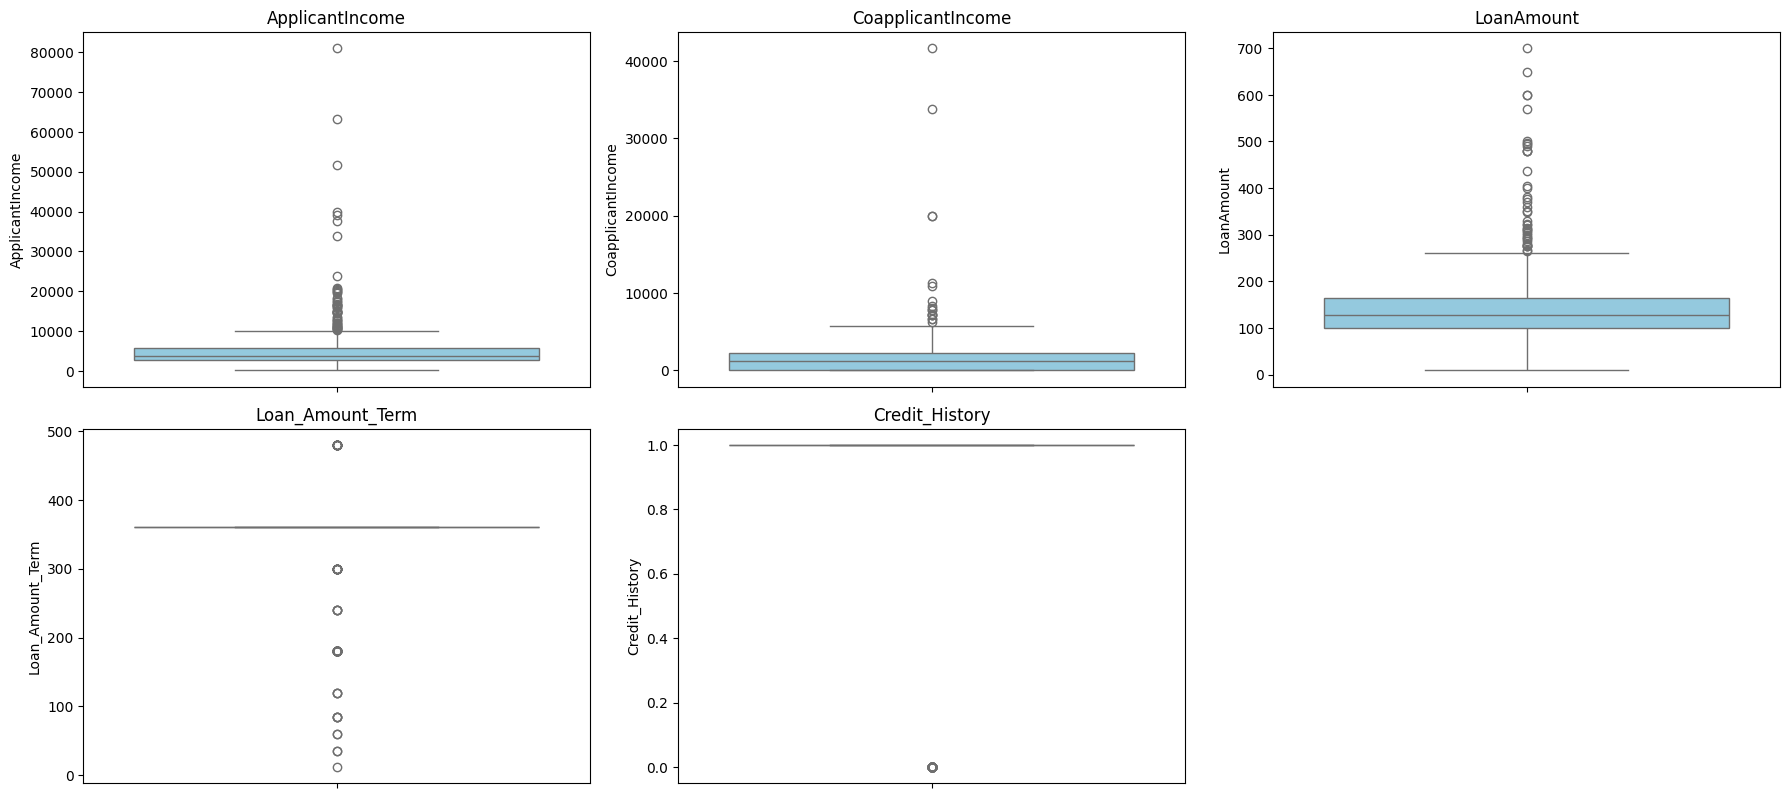

In [26]:
plt.figure(figsize=(18,12))

for i, col in enumerate(numericalcolm):
    plt.subplot((len(numericalcolm)+2)//2, 3, i+1)   # create colms rows and position for the plots (3*3) matrix created only 5 place used
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(col)

plt.tight_layout() ## adjust spaces in thr plot
plt.show()

INTERPRETATION: The box plot analysis indicates that ApplicantIncome, CoapplicantIncome, and LoanAmount contain several upper outliers, suggesting the presence of applicants with exceptionally high incomes and loan amounts. These variables have positively skewed distributions. In contrast, Loan_Amount_Term contains very few outliers, while Credit_History, being a binary variable, is not appropriate for box plot-based outlier detection.

In [27]:
for col in numericalcolm:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

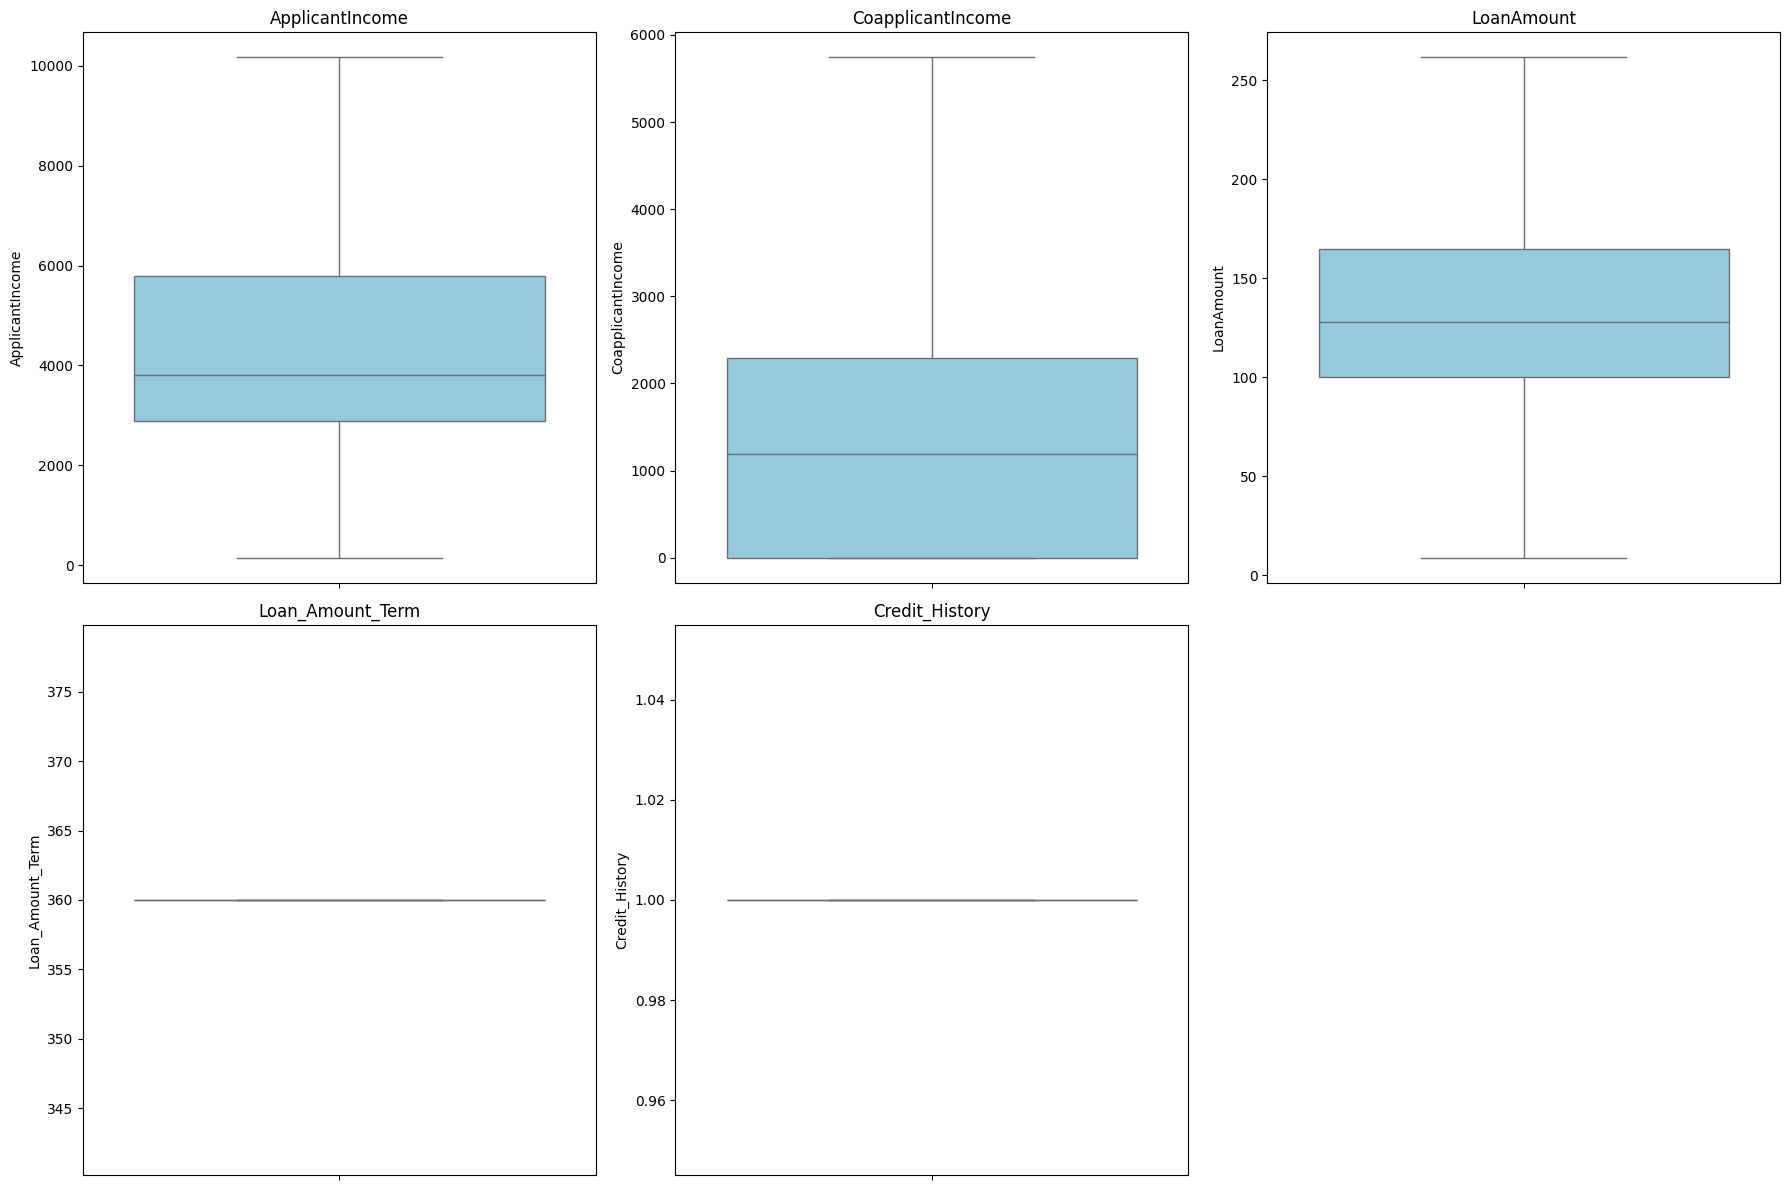

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18,12))

for i, col in enumerate(numericalcolm):
    plt.subplot((len(numericalcolm)+2)//3, 3, i+1)
    sns.boxplot(y=df[col], color='Skyblue')
    plt.title(col)

plt.tight_layout()
plt.show()                  #Expected result: Most or all of the outlier dots should disappear because the extreme values have been capped.

In [29]:
print(df.shape)   # remain same show that extreme points are caped

(614, 13)


# **PHASE 4 : DATA PREPROCESSING**


In [30]:
## DROP COLM
print(df.columns)

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')


In [31]:
df = df.drop(columns=['Loan_ID'])

In [32]:
print(df.columns)

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')


In [33]:
## ENCODE CATEGORICAL VARIABLES
# we canot do direct machine learning (regression/logistic) through categorical so we encode them
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categorical_cols = ['Gender', 'Married', 'Dependents',
                    'Education', 'Self_Employed',
                    'Property_Area', 'Loan_Status']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849.0,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583.0,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000.0,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583.0,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000.0,0.0,141.0,360.0,1.0,2,1


# **Feature Scaling**

In [34]:
#Standard Scaler
from sklearn.preprocessing import StandardScaler
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome',
                  'LoanAmount', 'Loan_Amount_Term']
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols]) #fit() calculates the mean and SD of each column & transform() scales the values using those statistics.
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,0.497164,-0.874587,-0.168041,0.0,1.0,2,1
1,1,1,1,0,0,-0.013767,0.054395,-0.168041,0.0,1.0,0,0
2,1,1,0,0,1,-0.652632,-0.874587,-1.280462,0.0,1.0,2,1
3,1,1,0,1,0,-0.820924,0.578025,-0.311579,0.0,1.0,2,1
4,1,0,0,0,0,0.558104,-0.874587,0.065209,0.0,1.0,2,1


In [35]:
from sklearn.preprocessing import MinMaxScaler
numerical_cols = ['ApplicantIncome', 'CoapplicantIncome',
                  'LoanAmount', 'Loan_Amount_Term']
scaler = MinMaxScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,0.568692,0.000000,0.471287,0.0,1.0,2,1
1,1,1,1,0,0,0.442360,0.262575,0.471287,0.0,1.0,0,0
2,1,1,0,0,1,0.284396,0.000000,0.225743,0.0,1.0,2,1
3,1,1,0,1,0,0.242784,0.410578,0.439604,0.0,1.0,2,1
4,1,0,0,0,0,0.583760,0.000000,0.522772,0.0,1.0,2,1


# **Phase 5: Train-Test Split**

In [36]:
from sklearn.model_selection import train_test_split
# Independent Variables
X = df.drop('Loan_Status', axis=1)
# Target (Dependent Variable)
y = df['Loan_Status']
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.20, random_state=42) # random state ensures that the train-test split is reproducible, so the same rows are selected each time the code is executed.
# Check the shape of the datasets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (491, 11)
X_test shape: (123, 11)
y_train shape: (491,)
y_test shape: (123,)


# **Phase 6: Model Building**

In [47]:
## LOGISTICS REGRESSION
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
# Predictions
y_pred_lr = lr.predict(X_test)
# Accuracy
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
# Confusion Matrix                  #Shows correct and incorrect predictions
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))

# Classification Report
print("Classification Report")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.6504065040650406
Confusion Matrix
[[ 0 43]
 [ 0 80]]
Classification Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        43
           1       0.65      1.00      0.79        80

    accuracy                           0.65       123
   macro avg       0.33      0.50      0.39       123
weighted avg       0.42      0.65      0.51       123



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [48]:
##DECISION TREE
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
# Accuracy
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))
# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.5609756097560976

Confusion Matrix
[[14 29]
 [25 55]]

Classification Report
              precision    recall  f1-score   support

           0       0.36      0.33      0.34        43
           1       0.65      0.69      0.67        80

    accuracy                           0.56       123
   macro avg       0.51      0.51      0.51       123
weighted avg       0.55      0.56      0.56       123



In [49]:
# RANDOM FOREST
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
# Accuracy
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.6178861788617886

Confusion Matrix
[[ 3 40]
 [ 7 73]]

Classification Report
              precision    recall  f1-score   support

           0       0.30      0.07      0.11        43
           1       0.65      0.91      0.76        80

    accuracy                           0.62       123
   macro avg       0.47      0.49      0.43       123
weighted avg       0.53      0.62      0.53       123



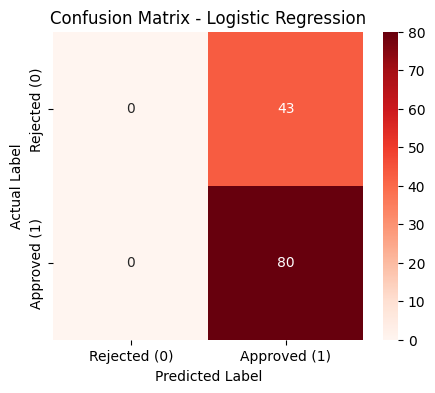

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)

# Plot Heatmap
plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Reds',
            xticklabels=['Rejected (0)', 'Approved (1)'],
            yticklabels=['Rejected (0)', 'Approved (1)'])

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

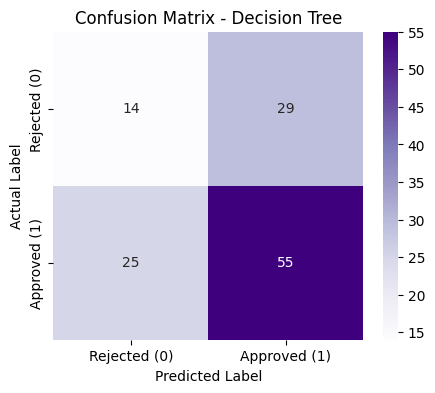

In [56]:
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Purples',
            xticklabels=['Rejected (0)', 'Approved (1)'],
            yticklabels=['Rejected (0)', 'Approved (1)'])

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

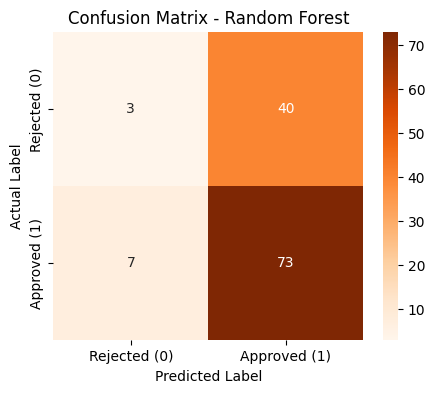

In [55]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Oranges',
            xticklabels=['Rejected (0)', 'Approved (1)'],
            yticklabels=['Rejected (0)', 'Approved (1)'])

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [ ]:
# k fold
#SMOTE